In [1]:
import os

# 切换到上层文件夹
os.chdir("..")

# 验证
print("当前工作目录:", os.getcwd())

当前工作目录: /Users/sunshine8641/Code/OOD


In [2]:
import os
import torch
import torch.nn as nn
from accelerate import Accelerator
from data_utils.build_dataset import build_id_dataloaders,build_ood_dataloaders,build_jigsaw_dataloaders
from methods import forward_base,calculate_layer_norm
from models import get_model,ParametricBReLU,ParametricBoundedLeakyReLU,BoundedPReLU
from utils import get_args, merge_args_with_config, load_config, accuracy, MetersGroup,\
format_meters_log
from safetensors.torch import load_file
from collections import OrderedDict
from metrics import  *
from  methods import *
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt
from train.train_utils import load_clean_model_state
from eval import exp_base,  initialize_experiment
from data_utils.transforms import get_ood_transform,get_id_transform


from utils import *

In [3]:
args = argparse.Namespace()
args.config="configs/base_cifar_resnet.yaml"# get_args()
if args.config:
    cfg = load_config(args.config)
    config = merge_args_with_config(args, cfg)
else:
    config = vars(args)  # 如果没有配置文件，直接用args
print(config)

{'exp_name': 'resnet18_cifar100_relu', 'id_dataset': {'name': 'cifar100', 'root': '/Users/sunshine8641/Code/Data/'}, 'ood_dataset': {'name': 'svhn', 'root': '/Users/sunshine8641/Code/Data/'}, 'top_5': False, 'model': {'type': 'resnet18_cifar', 'pretrained': False, 'num_classes': 100, 'activation': 'relu', 'last_block_activation': 'relu'}, 'num_classes': 100, 'test_model': 'base_best', 'start_epoch': 0, 'epochs': 200, 'lr': 0.1, 'min_lr': 0, 'weight_decay': 5e-05, 'mixed_precision': 'fp16', 'batch_size': 128, 'num_workers': 4, 'momentum': 0.9, 'optimizer': 'SGD', 'scheduler': 'cosine', 'step_gamma': 0.1, 'step_size': 30, 'train_method': 'base', 'use_swa': False, 'swa_window': 40, 'swa_start': 0, 'label_smooth': True, 'smoothing': 0.1, 'teacher': {'type': 'resnet34_cifar', 'pretrained': False, 'num_classes': 100}, 'teacher_path': 'resnet34_base.pt', 'distill_alpha': 0.5, 'distill_temperature': 4.0, 'log': {'log_dir': './logs', 'use_loguru': True}, 'odin_temperature': 1000.0, 'odin_magnit

In [4]:
config["mixed_precision"]='no'

accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)


[Test] Loading OOD Dataloader for svhn...
mps


<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  Prepare Experiment
</h1>

In [5]:
n_iter=len(id_test_loader)
tr=get_id_transform(cfg['id_dataset']['name'])
for t in tr[0].transforms:
    if isinstance(t, transforms.Normalize):
        print("Mean:", t.mean)
        mean=t.mean
        print("Std:", t.std)
        std=t.std

Mean: (0.5071, 0.4865, 0.4409)
Std: (0.2673, 0.2564, 0.2762)


ID Train Batch: x.shape=torch.Size([128, 3, 32, 32]), y.shape=torch.Size([128])
图像已保存到: Figs/x.png


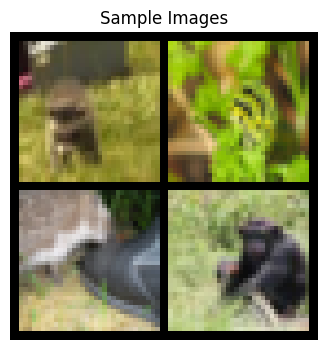

In [6]:
for batch in id_val_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}, y.shape={y.shape}")
    break
show_images(x, y,mean,std, n=4)

In [7]:
model.eval()
test_meters.reset()
with torch.no_grad():
    for inputs, targets in id_test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        topk_acc = accuracy(outputs, targets, topk=top_k)
        acc_dict = {f"Acc@{k}": acc.item() for k, acc in zip(top_k, topk_acc)}
        acc_dict["Loss"] = loss.item()
        test_meters.update(acc_dict, n=targets.size(0))
log_str = format_meters_log(0, test_meters.meters,0, None, prefix="Val Epoch")
print(log_str)

Val Epoch 0 | Loss: 1.1945 | Acc@1: 73.70% | Time: 0.00


In [8]:
norm_funcs=[l2norm,lambda x: adaptive_topk_channel_weight(x, k_min=0.05, k_max=0.2,alpha =0.5,eps=1e-8)]


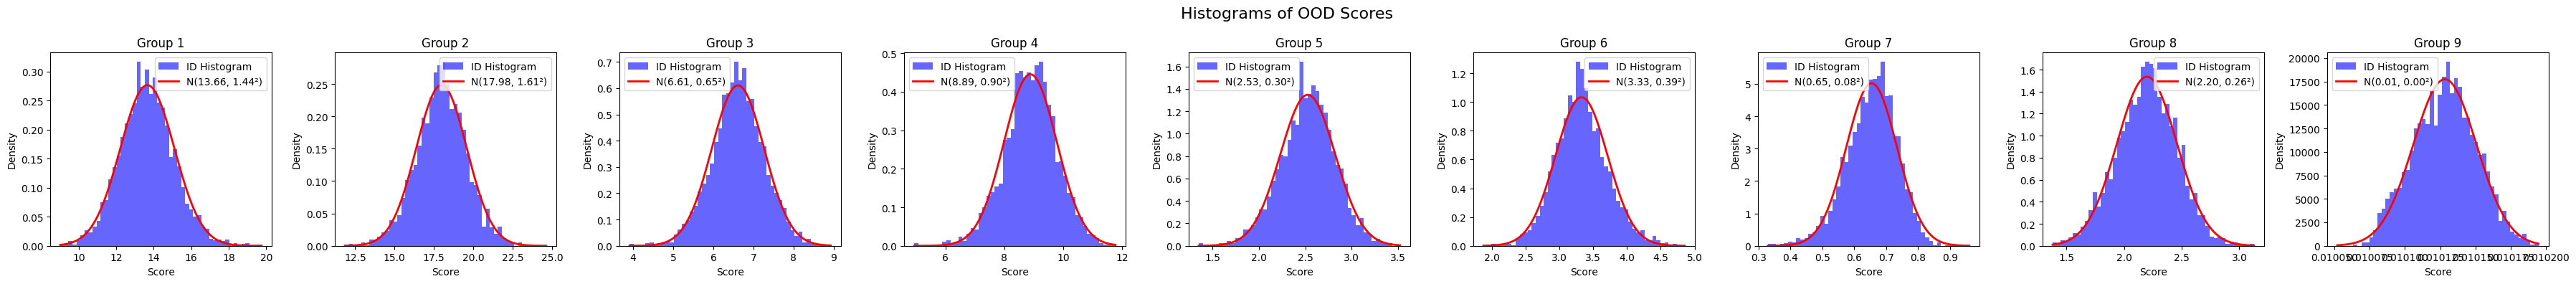

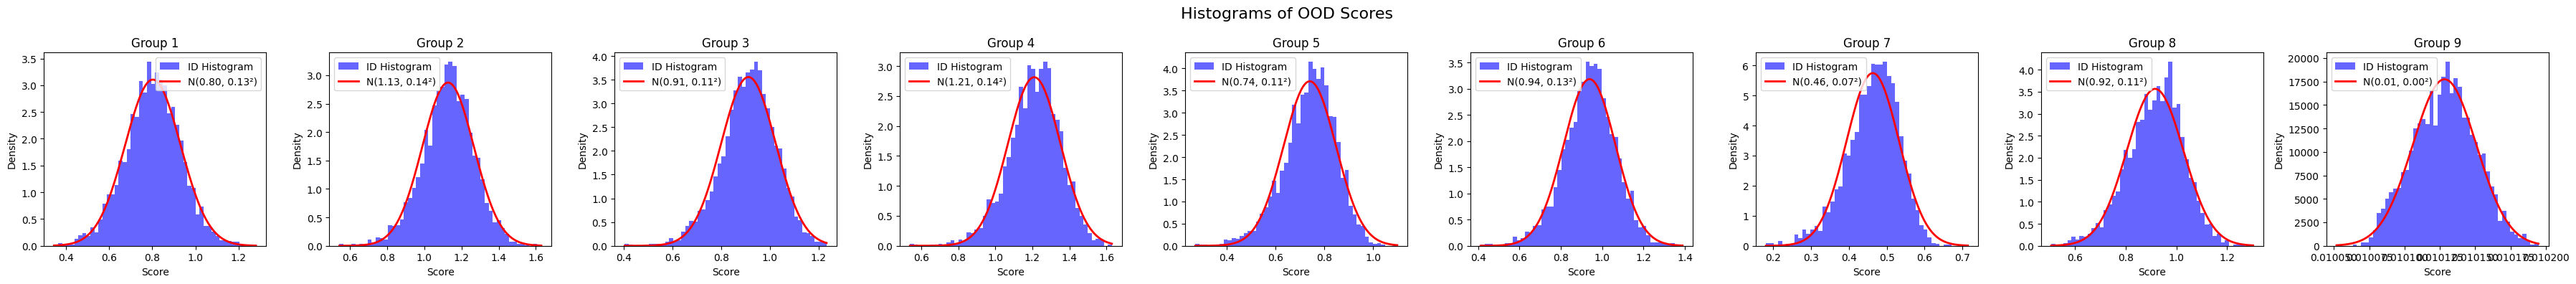

[array([1.90085235e+01, 2.33799159e+01, 8.52939697e+00, 1.14524606e+01,
       3.39522773e+00, 4.65502783e+00, 8.96904756e-01, 3.00611630e+00,
       1.01890617e-02]), array([1.1893024 , 1.54511314, 1.21802573, 1.57584688, 1.02360843,
       1.33130327, 0.63970136, 1.24399497, 0.01018906])]
[array([1.03585092e+01, 1.40929066e+01, 5.04112551e+00, 6.55933564e+00,
       1.80253005e+00, 2.44891515e+00, 4.34597165e-01, 1.58275195e+00,
       1.00807703e-02]), array([0.48841866, 0.76237849, 0.62726968, 0.83215904, 0.43915088,
       0.61056719, 0.27276503, 0.61770509, 0.01008077])]


In [9]:
QE=[]
QS=[]
id_output_based_scores = get_all_scores(
                model, id_val_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
for norm_func in norm_funcs:
    id_block_norms_scores=get_all_activation_strength(model, id_val_loader, norm_func,n_iter)
    id_all_scores=id_block_norms_scores+[id_output_based_scores]
    means, stds,qs,qe=compute_id_statistics(id_all_scores,qs=1,qe=99.9)
    QE.append(qe)
    QS.append(qs)
    plot_histograms_one(id_all_scores,means,stds, bins=50, title="Histograms of OOD Scores")        
print(QE)
print(QS)  


In [ ]:
id_all_scores

<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset1: SHVN
</h1>

[Test] Loading OOD Dataloader for svhn...
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32]), y.shape=torch.Size([128])
图像已保存到: Figs/x.png


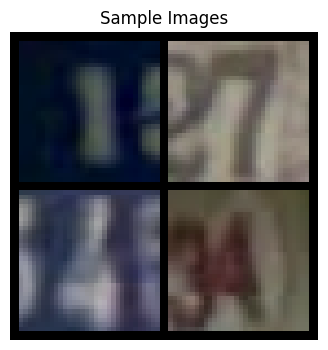

In [ ]:
cfg["ood_dataset"]["name"]="svhn"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}, y.shape={y.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x32c49f4c0>


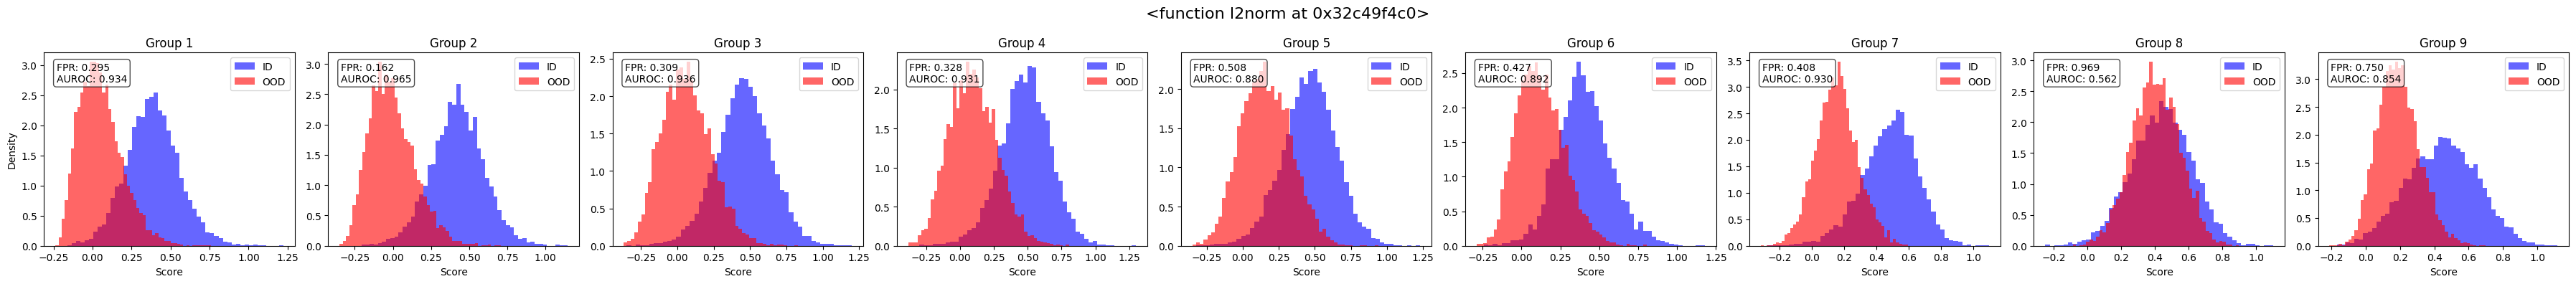

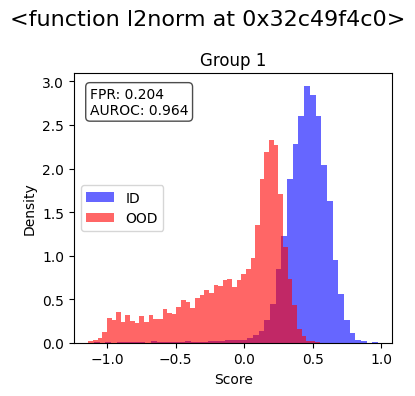

<function <lambda> at 0x330c31da0>


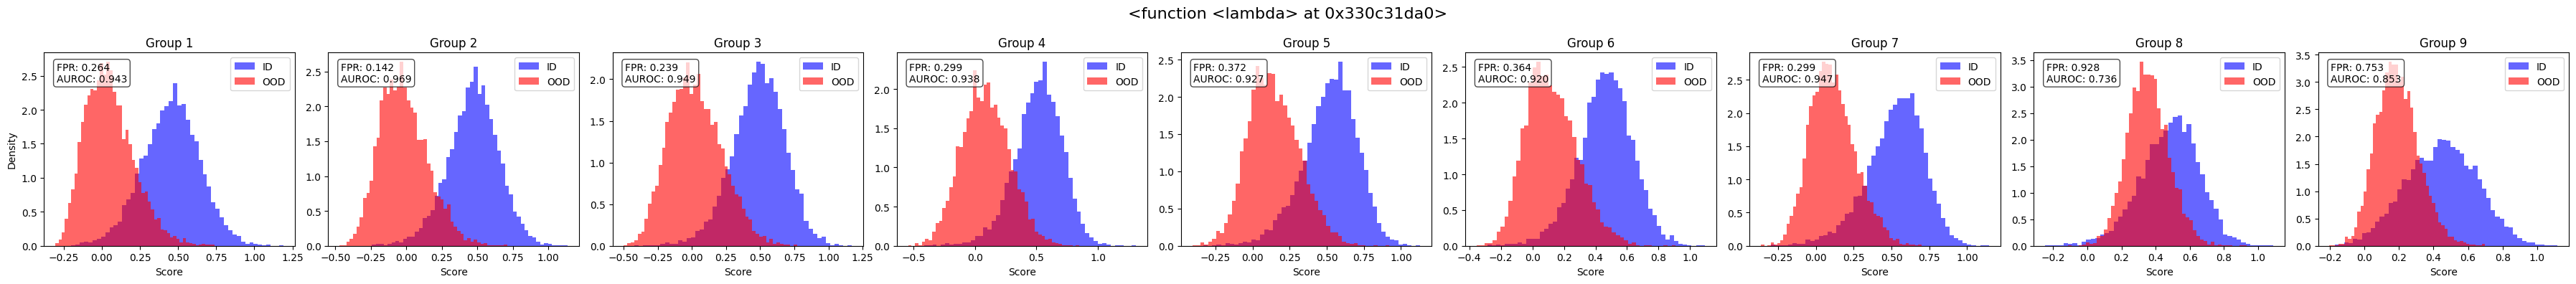

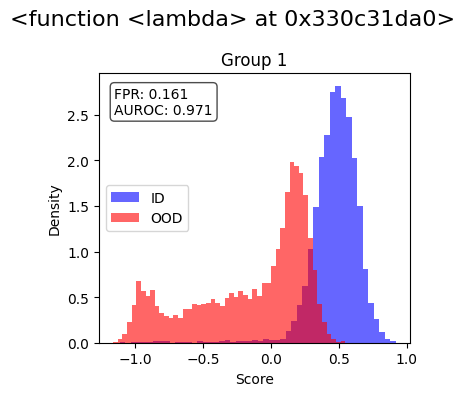

: 

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



In [ ]:
scores_out_all_standard.shape

(8, 7040)

<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset2: Textures
</h1>

[Test] Loading OOD Dataloader for textures...
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


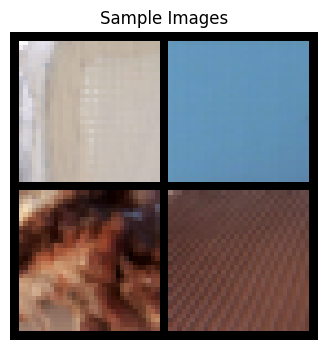

In [ ]:
cfg["ood_dataset"]["name"]="textures"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x30fde4680>


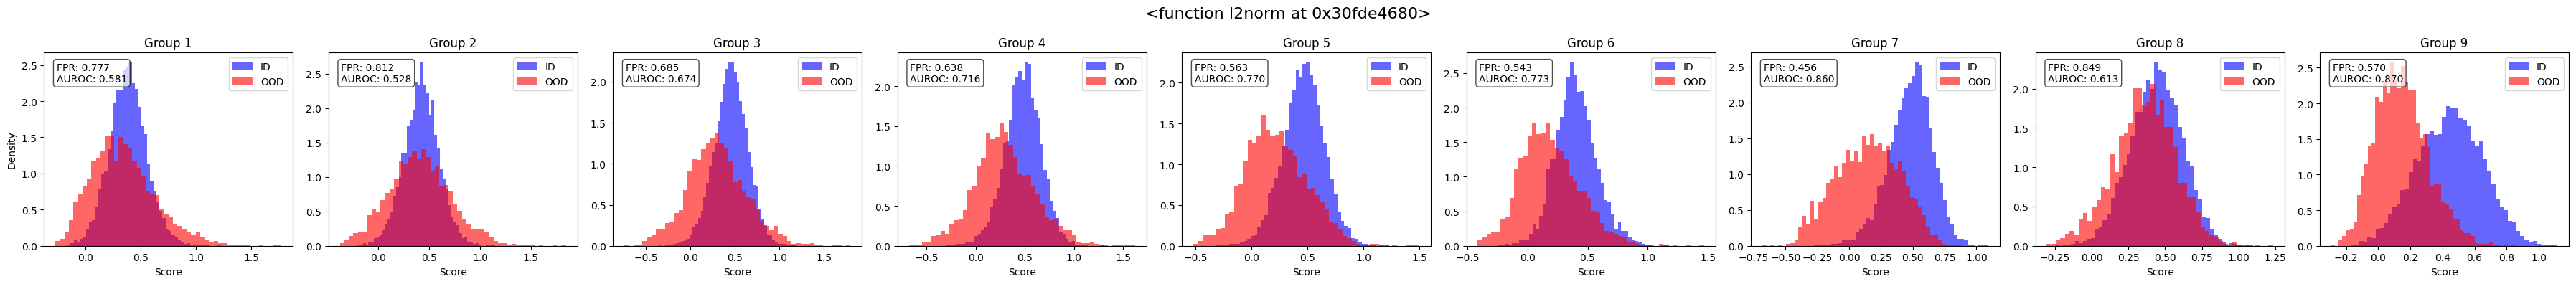

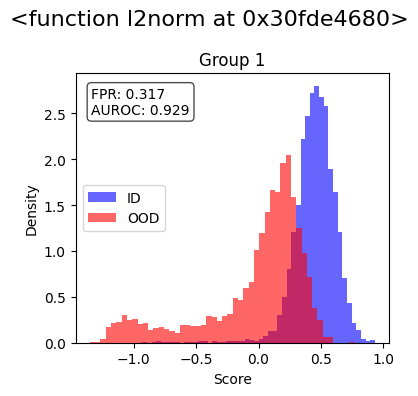

<function <lambda> at 0x3281dcf40>


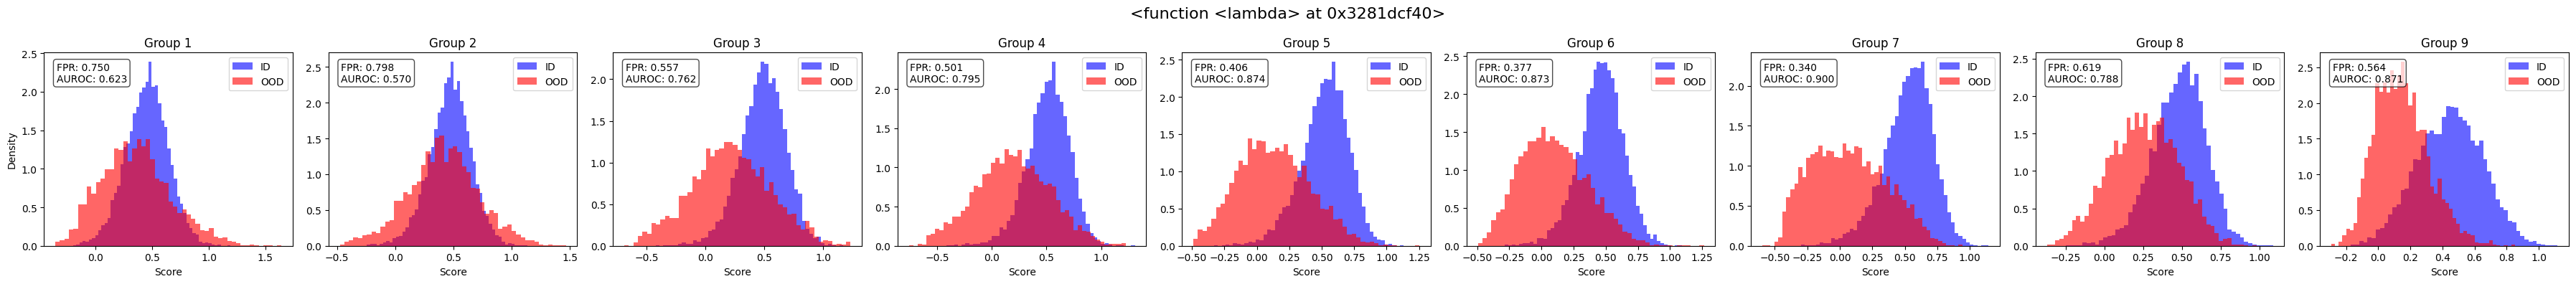

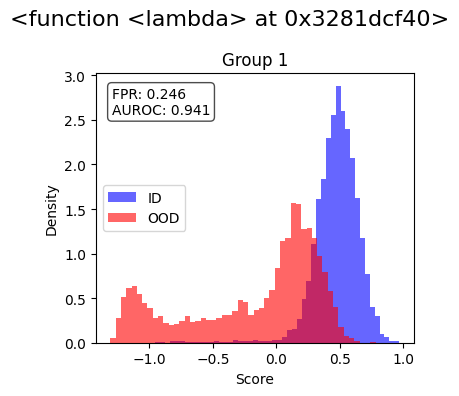

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset3: LSUN-R
</h1>

[Test] Loading OOD Dataloader for LSUN_R...
/Users/sunshine8641/Code/Data/LSUN_R
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


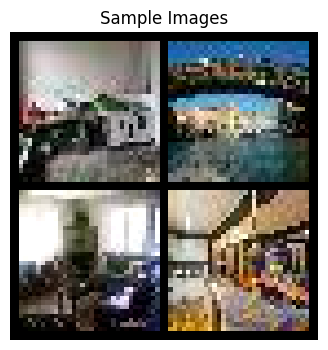

In [ ]:
cfg["ood_dataset"]["name"]="LSUN_R"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x30fde4680>


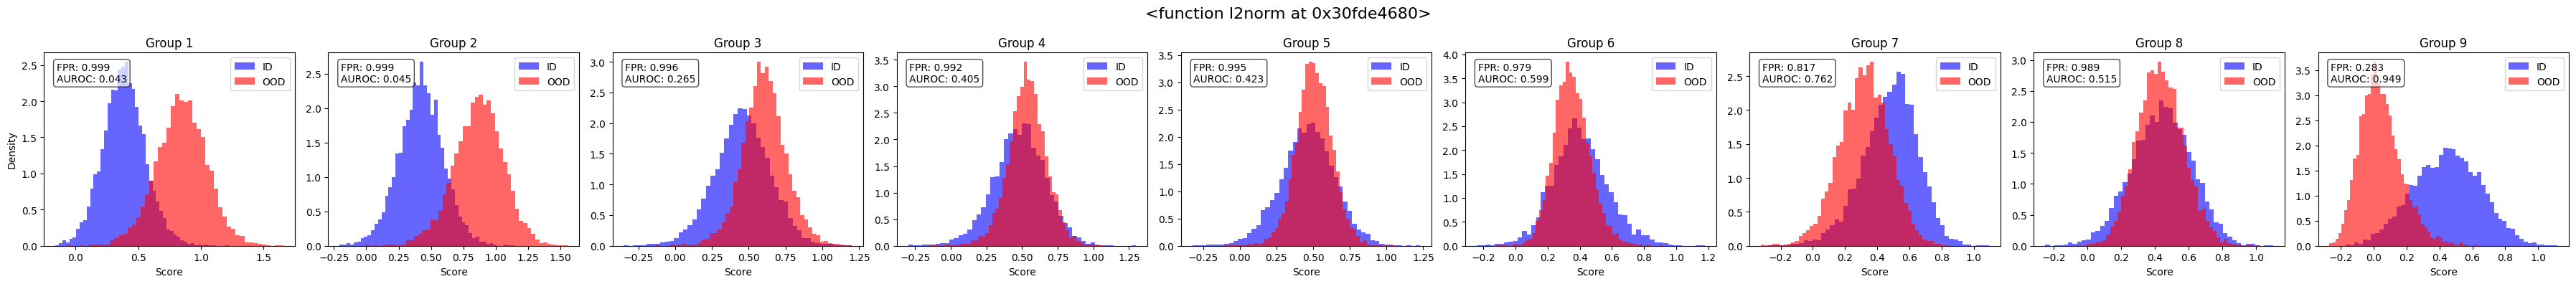

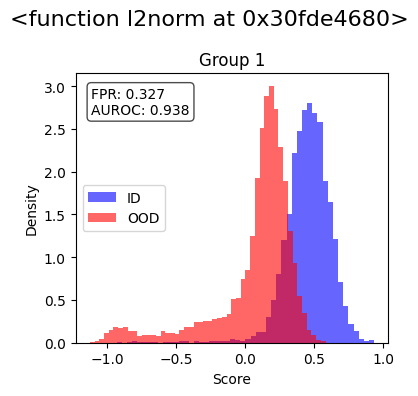

<function <lambda> at 0x3281dcf40>


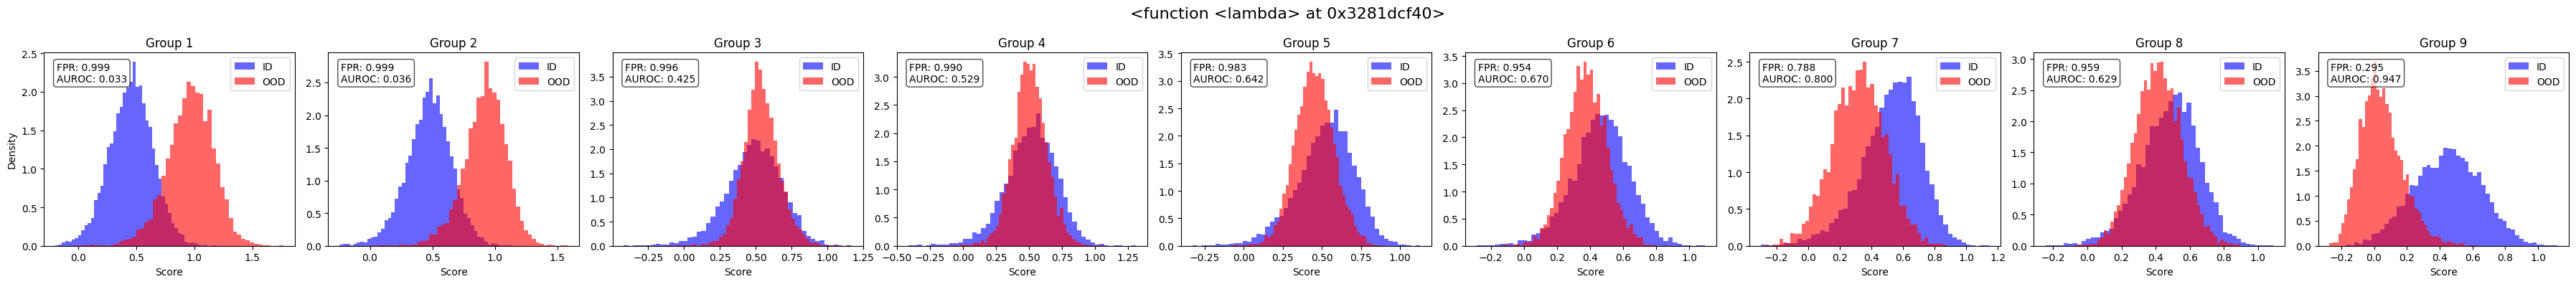

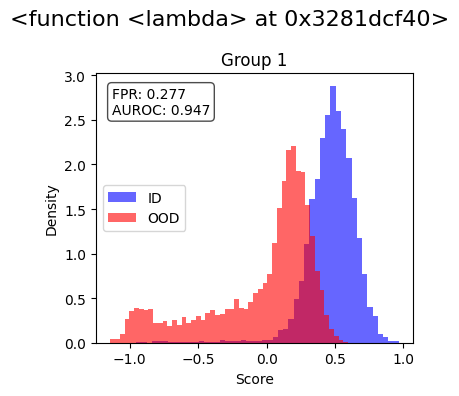

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset4: LSUN-C
</h1>

[Test] Loading OOD Dataloader for LSUN_C...
/Users/sunshine8641/Code/Data/LSUN_C
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


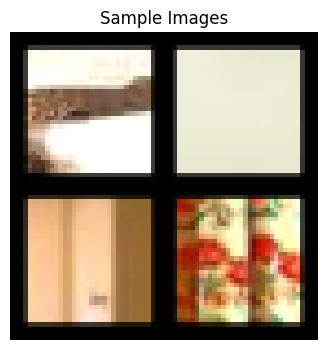

In [ ]:
cfg["ood_dataset"]["name"]="LSUN_C"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x30fde4680>


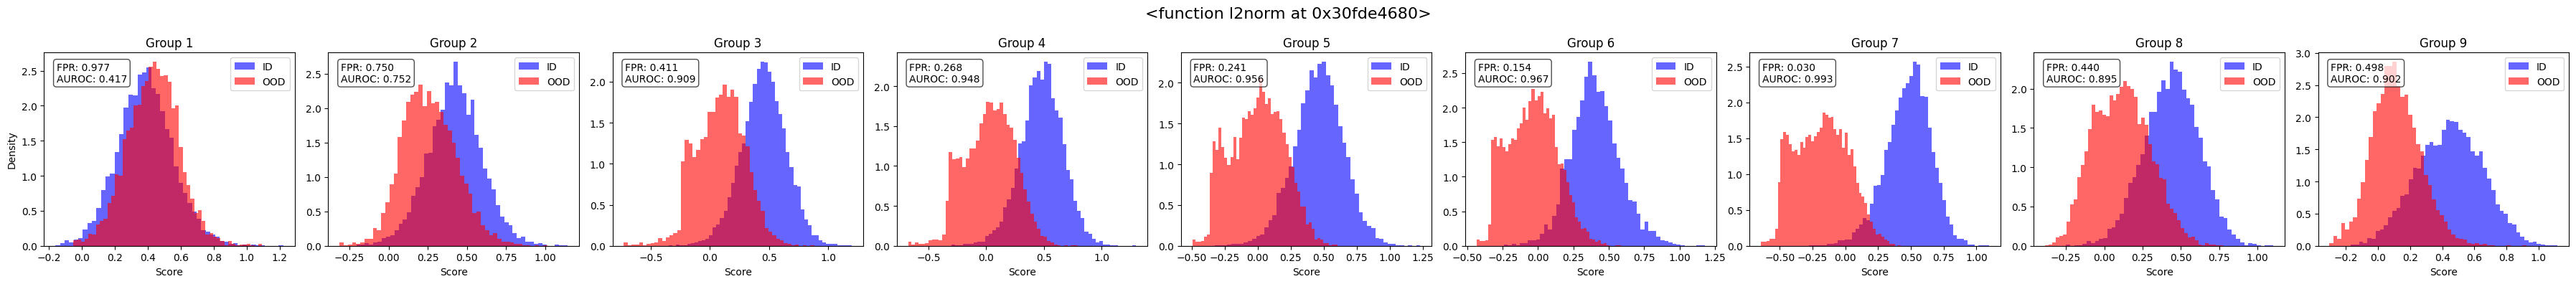

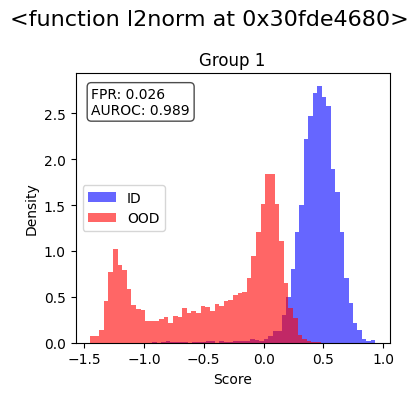

<function <lambda> at 0x3281dcf40>


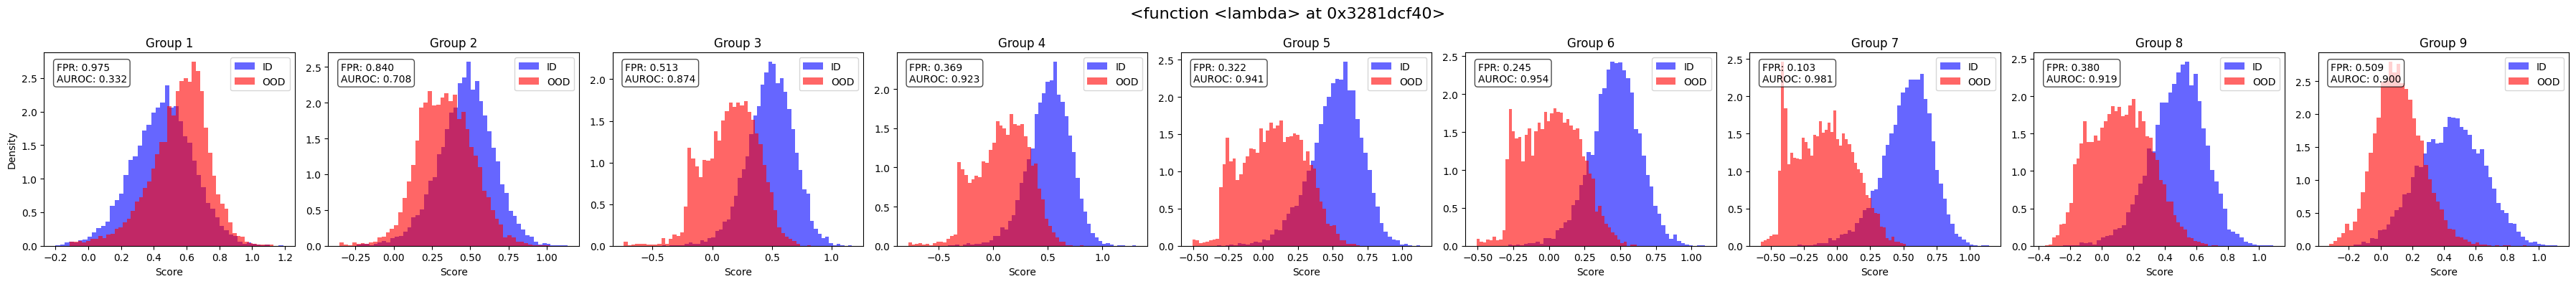

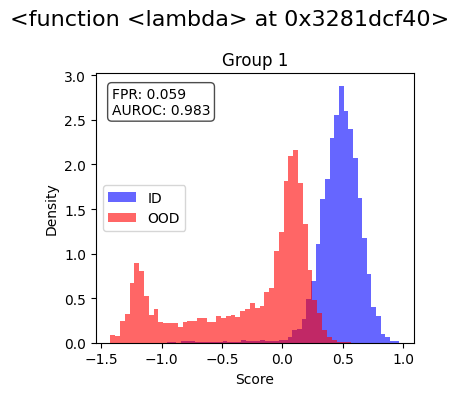

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset5: iSUN
</h1>

[Test] Loading OOD Dataloader for iSUN...
/Users/sunshine8641/Code/Data/iSUN
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


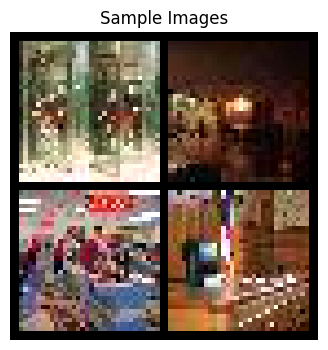

In [ ]:
cfg["ood_dataset"]["name"]="iSUN"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x30fde4680>


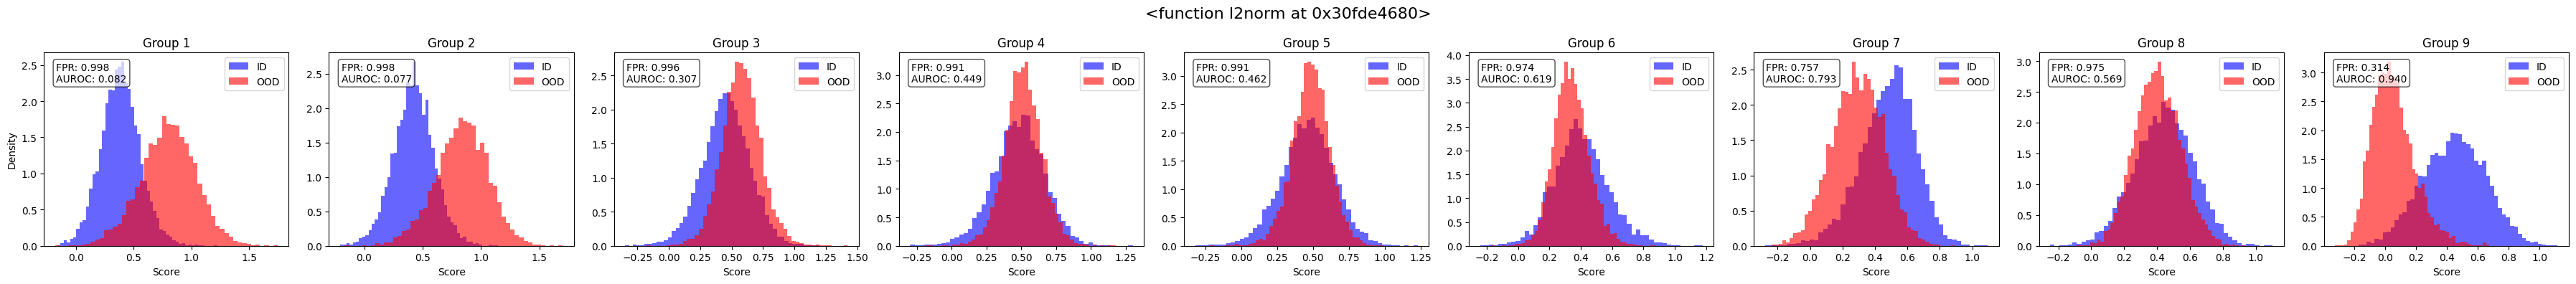

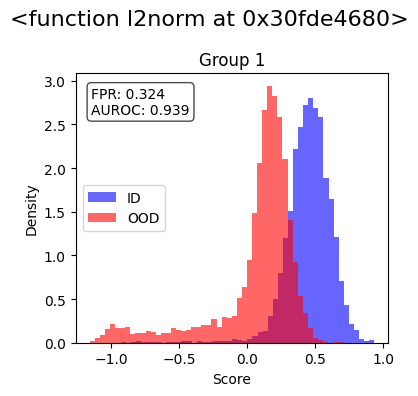

<function <lambda> at 0x3281dcf40>


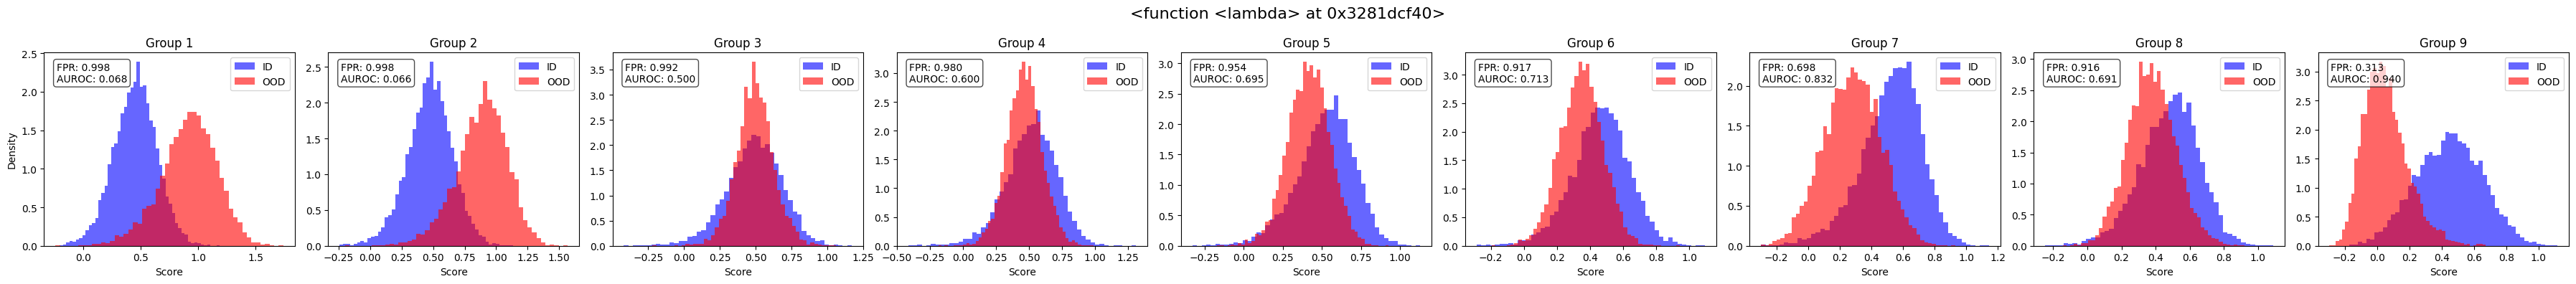

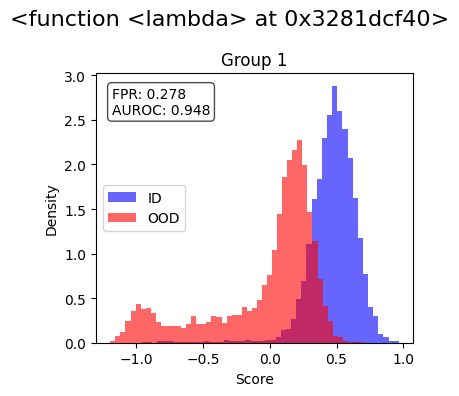

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset6: PLACES
</h1>

[Test] Loading OOD Dataloader for Places...
/Users/sunshine8641/Code/Data/Places
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


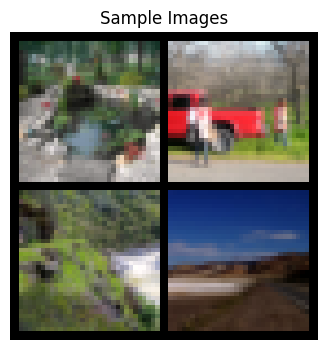

In [ ]:
cfg["ood_dataset"]["name"]="Places"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x30fde4680>


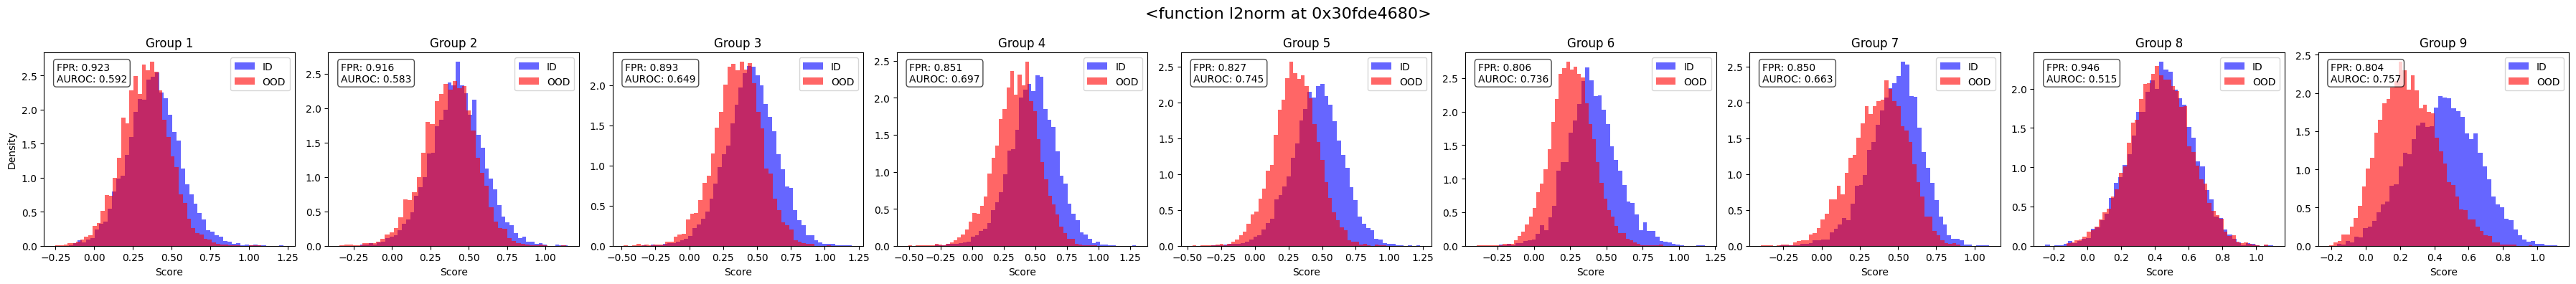

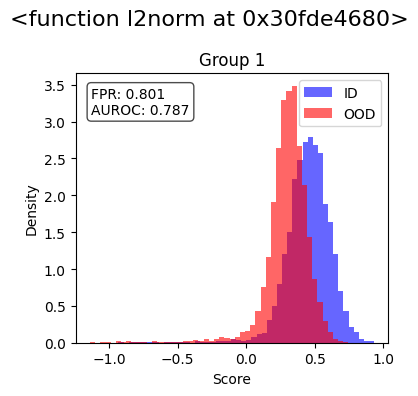

<function <lambda> at 0x3281dcf40>


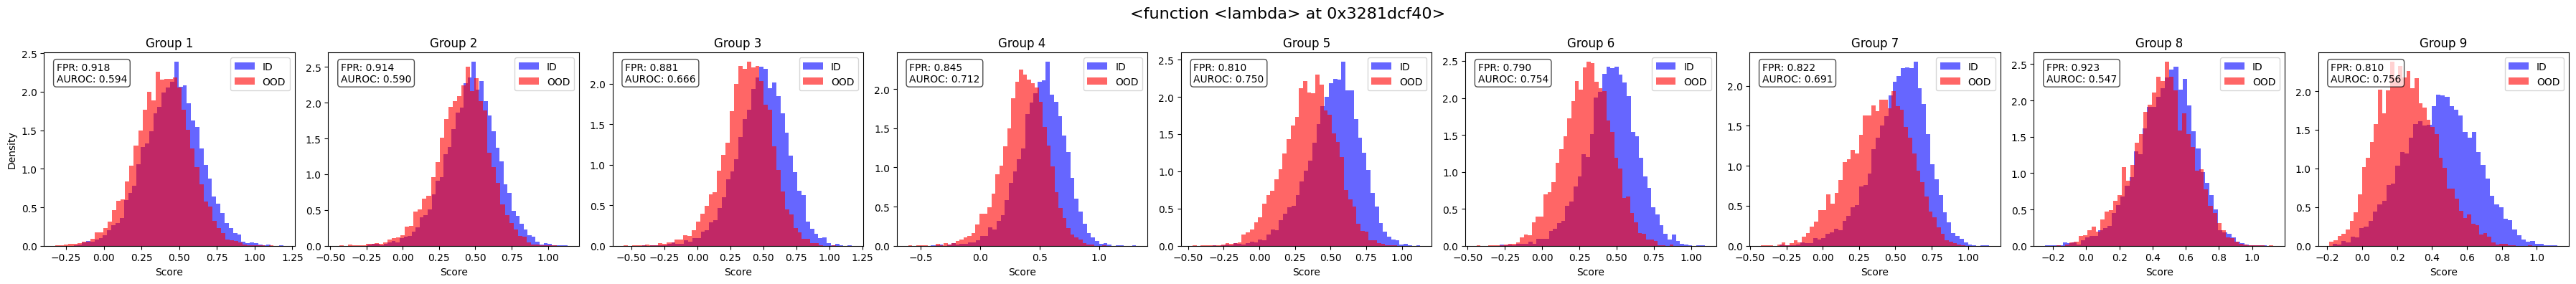

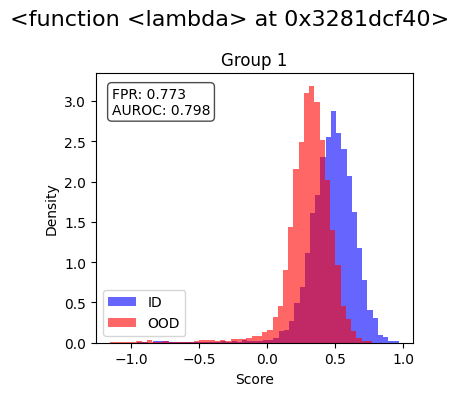

In [ ]:
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
for i in range(0,len(norm_funcs)):
    print(norm_funcs[i])
    id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

    id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    id_all_scores=id_block_norms_scores+[id_output_based_scores]

    ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
    ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
    ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
    scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
    scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
    plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
    scores_strong_out=scores_out_all_standard[strong_expert_index,:]
    scores_weak_out=scores_out_all_standard[weak_expert_index,:]
    scores_strong_in=scores_in_all_standard[strong_expert_index,:]
    scores_weak_in=scores_in_all_standard[weak_expert_index,:]
    fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
    fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
    plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

